# Medium-sized Inversions
Here, we visualize the inversions that were identified for the `medium` treatment across the range of depths for the **90% threshold** called variants. An extra consideration here is that with the deconvolution-during-concatenation step, Harpy was unable to call variants on the 10X and 20X data because there were too many molecules (more than the 96^4 possible with haplotagging).

In [1]:
library(ggplot2)

read_data <- function(size_treatment, depth){
    truthfile <- paste0("simulated_data/inversions/", size_treatment, "/inv.", size_treatment,".vcf")
    samplesfile <- paste("simulated_data/called_sv/leviathan90", size_treatment, depth , "by_sample/inversions.bedpe", sep = "/")
    poolfile <- paste("simulated_data/called_sv/leviathan90", size_treatment, depth, "by_pop/inversions.bedpe", sep = "/")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$sample <- factor(c("simulated_inversions"))

    sample_inversions <- read.table(
        paste("simulated_data/called_sv/leviathan90", size_treatment, depth, "by_sample/inversions.bedpe", sep = "/"),
        header = T
    )[,1:4]
    sample_inversions$sample <- as.factor(sample_inversions$sample)
    if(file.exists(poolfile)){
        pooled_inversions <- read.table(poolfile, header = T)
        pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
        names(pooled_inversions)[1] <- "sample"
        if(nrow(pooled_inversions > 0)){
            pooled_inversions$sample <- factor(paste("pooled", depth, size_treatment, sep = "_"))
        }
    } else {
        # get an empty copy
        pooled_inversions <- sample_inversions[0, ]
    }
    return(
        rbind(true_inversions, sample_inversions, pooled_inversions)
    )
}
plot_data <- function(data, size_treatment, depth){
    axis_ticks <- c(paste0("sample_", sprintf("%02d", 1:10), ".", depth), "simulated_inversions")
    ggplot(
        data,
        aes(
            x = position_start,
            xend = position_end,
            y = sample,
            yend = sample,
            color = sample
        )
    ) +
        scale_x_continuous(labels = scales::comma) +
        scale_y_discrete(limits = axis_ticks) +
        labs(title = "Called Inversions", subtitle = paste(size_treatment, depth), x = "genomic position (bp)", caption = "Simulated inversions (groundtruth) shown in top row") + 
        geom_segment(linewidth = 2) +
        facet_wrap(~contig, ncol = 1, scales = "free_x") +
        theme_light() +
        theme(panel.grid.major.y = element_blank(), legend.position = "None")
}

Set a global variable `.size` to `"medium"` to avoid writing it each time

In [2]:
.size <- "medium"

## 0.5X depth

In [3]:
depth_05X <- read_data(.size, "05X")
tail(depth_05X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
11,3R,24237377,24380766,simulated_inversions
12,3R,26216293,26389606,simulated_inversions
13,3L,1700629,1761806,simulated_inversions
14,3L,6119288,6436722,simulated_inversions
15,3L,9943175,10123730,simulated_inversions
16,3L,21061086,21499573,simulated_inversions


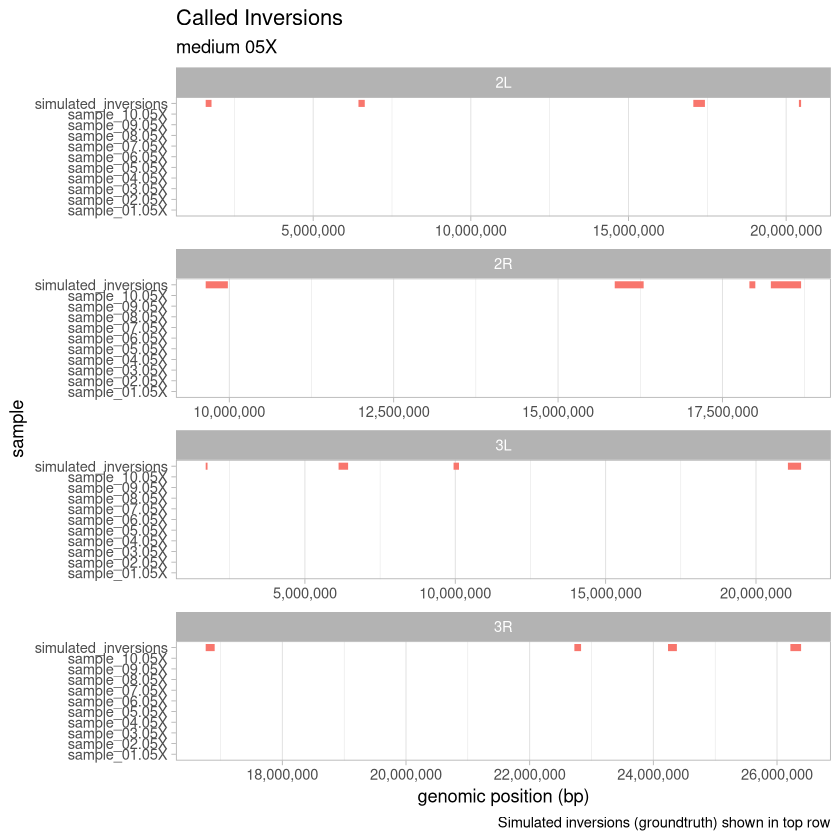

In [4]:
plot_data(depth_05X, .size, "05X")

## 2X Depth

In [5]:
depth_2X <- read_data(.size, "2X")
tail(depth_2X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
40,2R,15862082,16302028,sample_02.2X
41,3R,24237375,24380767,sample_02.2X
42,2L,20404849,20474311,sample_06.2X
43,2R,18236489,18696638,sample_06.2X
44,3R,22722815,22831351,sample_06.2X
45,2L,17056242,17424245,sample_10.2X


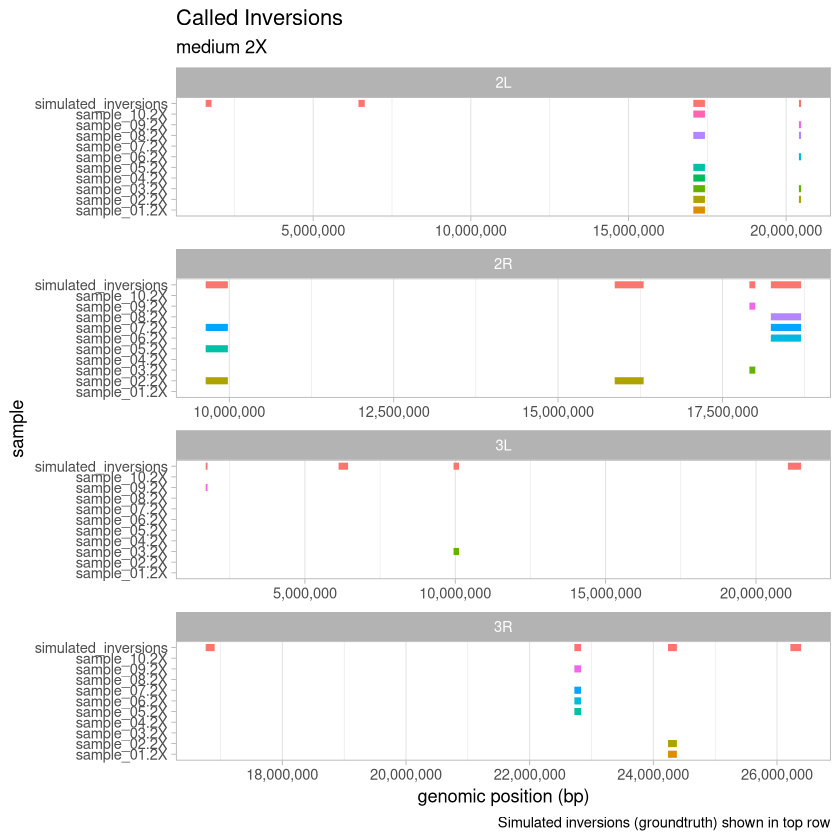

In [6]:
plot_data(depth_2X, .size, "2X")

## 5X Depth

In [7]:
depth_5X <- read_data(.size, "5X")
tail(depth_5X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
75,2L,20404849,20474311,sample_03.5X
76,3L,9943174,10123730,sample_03.5X
77,2R,9640873,9978281,sample_03.5X
78,2R,17910284,18000549,sample_03.5X
79,2R,18236489,18696638,sample_03.5X
80,3R,24237378,24380767,sample_03.5X


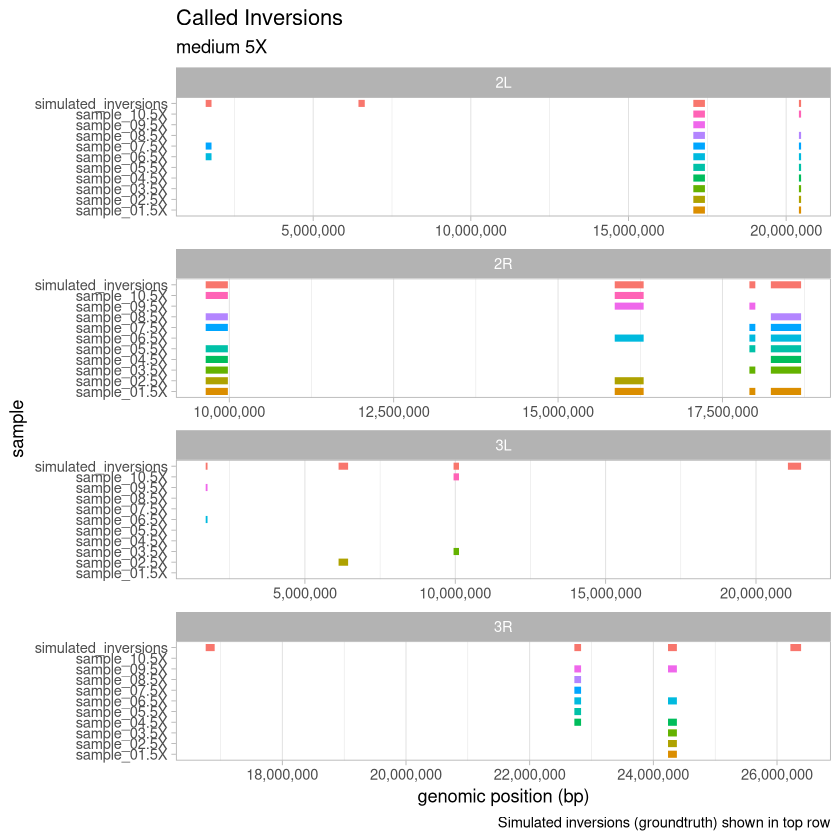

In [8]:
plot_data(depth_5X, .size, "5X")

## 10X Depth

In [9]:
depth_10X <- read_data(.size, "10X")
tail(depth_10X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
95,2R,9640873,9978281,sample_09.10X
96,2R,15862082,16302028,sample_09.10X
97,2R,17910284,18000549,sample_09.10X
98,2R,18236489,18696638,sample_09.10X
99,3R,22722815,22831351,sample_09.10X
100,3R,24237375,24380764,sample_09.10X


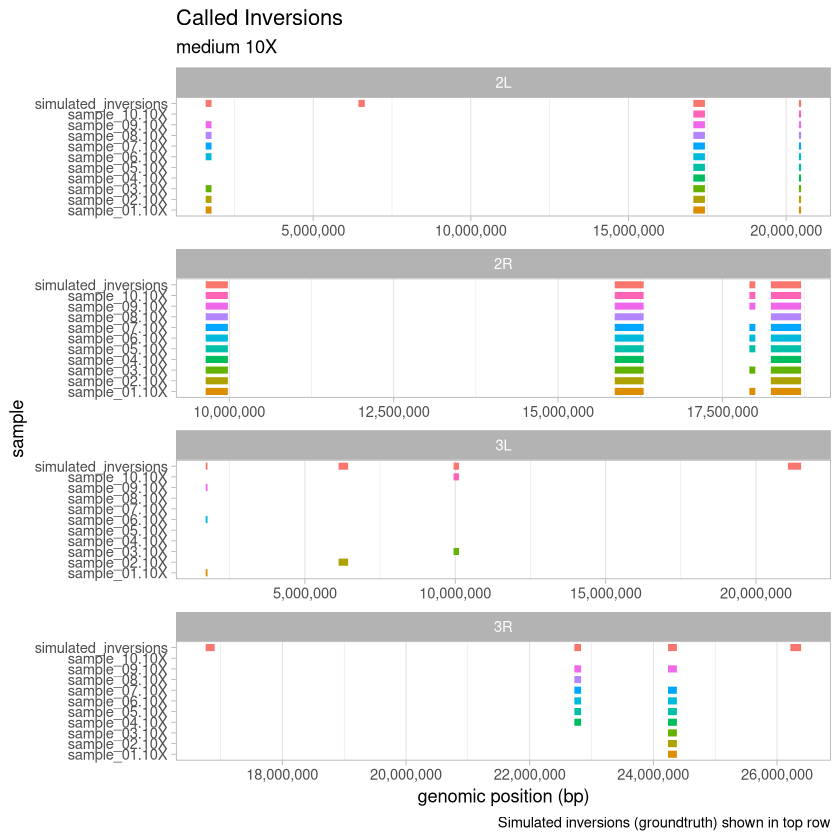

In [10]:
plot_data(depth_10X, .size, "10X")

## 20X Depth

In [11]:
depth_20X <- read_data(.size, "20X")
tail(depth_20X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
103,2R,9640873,9978281,sample_09.20X
104,2R,15862082,16302028,sample_09.20X
105,2R,17910284,18000549,sample_09.20X
106,2R,18236489,18696638,sample_09.20X
107,3R,22722815,22831351,sample_09.20X
108,3R,24237375,24380764,sample_09.20X


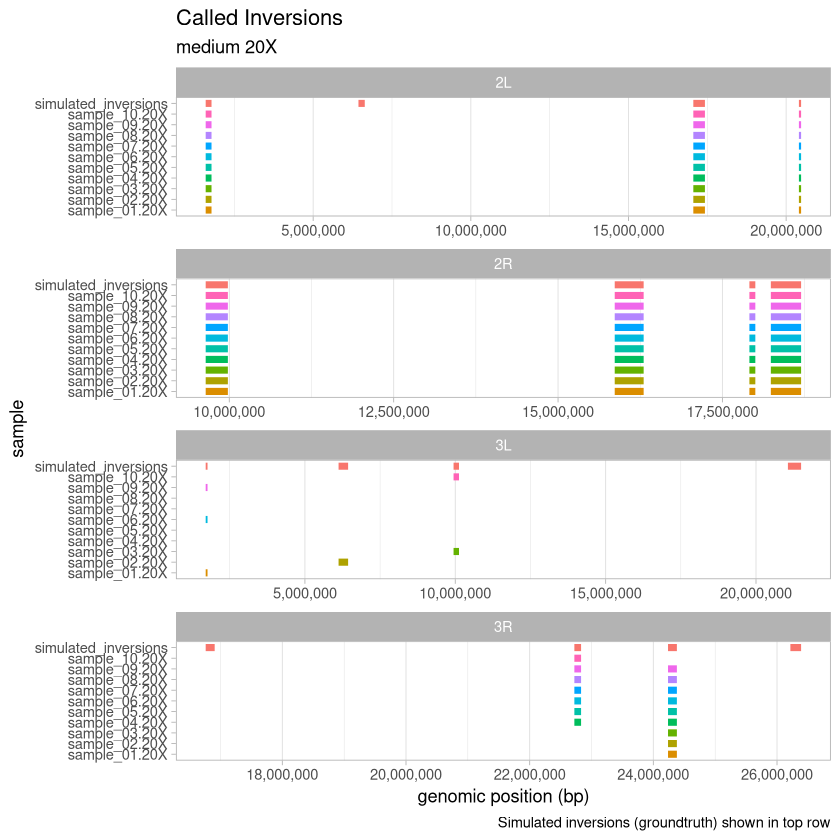

In [12]:
plot_data(depth_20X, .size, "20X")